# 🤖 The-Model-Traider – Asset-Level Forecasting with Prophet & Optuna

This notebook encapsulates the development of the `trainer()` function, a reusable forecasting routine built with:

- 📈 [Prophet](https://facebook.github.io/prophet/) for time series prediction  
- 🧪 [Optuna](https://optuna.org/) for hyperparameter optimization  
- 🛠️ Modular packaging into a `.py` script for scalable reuse

The trainer is designed to forecast asset prices for financial tickers using historical data from Yahoo Finance. It integrates robust cross-validation, RMSE-based optimization, and logistic or linear growth models depending on asset behavior.

The final pipeline includes:

- Data ingestion for any financial instrument  
- Parametric model tuning over multiple trials  
- Visual forecast generation (optional)  
- Model persistence to `.pkl` for future use  
- Execution time tracking for performance evaluation

> This modeling tool supports exploratory forecasting across ETFs, equities, and REITs — with future potential for portfolio-scale automation.

## Drive mount

In [2]:
#Se monta el Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Functiond & Tests

In [ ]:
def trainer(ticker, trials=1, FHi='2021-01-01', FHe="", ini=400, peri=10, hori=1, guardar=False, graficar=True, logi=False):
  import time
  start = time.time()

  '''
  Entrena un modelo Prophet para el ticker especificado usando optimización con Optuna.

  Parámetros:
  - ticker (str): símbolo del activo (ej. 'FUNO11.MX')
  - trials (int): número de iteraciones de búsqueda de hiperparámetros
  - FHi (str): fecha de inicio para descarga de datos (formato 'YYYY-MM-DD')
  - guardar (bool): si se desea guardar el modelo entrenado

  Retorna:
  - modelo (Prophet): objeto Prophet entrenado
  '''

  import yfinance as yf
  import pandas as pd
  import optuna
  import pickle
  import os
  import matplotlib.pyplot as plt
  from datetime import datetime, timedelta
  from prophet import Prophet
  from prophet.diagnostics import cross_validation, performance_metrics

  import logging
  optuna.logging.set_verbosity(optuna.logging.CRITICAL)
  for logger_name in ["cmdstanpy", "prophet"]:
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.CRITICAL)
    logger.propagate = False  # evita que se propague al logger raíz
    for handler in logger.handlers:
      logger.removeHandler(handler)


  ticker = ticker.upper()
  ticker_id = ticker.lower().replace('.', '').replace('-', '')
  if FHe == "":
    FHe = datetime.today().strftime('%Y-%m-%d')
  DatAss = yf.download(ticker, start=FHi, end=FHe, auto_adjust=True)['Close']

  df_prophet = DatAss.reset_index().copy()
  df_prophet['ds'] = DatAss.index
  df_prophet['y'] = df_prophet[ticker]
  df_prophet = df_prophet[['ds', 'y']]

  # Definir función objetivo para Optuna
  def objective(trial):

    # Hiperparámetros a optimizar
    growth_options = ['linear', 'logistic'] if logi else ['linear']
    growth = trial.suggest_categorical('growth', growth_options)
    changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True)
    holidays_prior_scale = trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True)
    weekly_seasonality = trial.suggest_categorical('weekly_seasonality', [True, False])

    # Si usamos crecimiento logístico, necesitamos agregar la columna 'cap'
    if growth == 'logistic':
      df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

    # Definir y entrenar modelo
    model = Prophet(
      growth=growth,
      changepoint_prior_scale=changepoint_prior_scale,
      seasonality_prior_scale=seasonality_prior_scale,
      holidays_prior_scale=holidays_prior_scale,
      weekly_seasonality=weekly_seasonality,
      daily_seasonality=True
    )
    model.fit(df_prophet)

    # Validación cruzada temporal
    df_cv = cross_validation(model, initial=f'{ini} days', period=f'{peri} days', horizon=f'{hori} days')
    df_perf = performance_metrics(df_cv)

    # Retornamos el RMSE promedio
    return df_perf['rmse'].mean()

  study = optuna.create_study(direction='minimize')
  study.optimize(objective, n_trials=trials)

  print('Best hiperparameters:')
  print(study.best_params)

  # Definir modelo con hiperparámetros óptimos
  modelo = Prophet(
    **study.best_params,
    daily_seasonality=True
  )
  # Entrenar sobre toda la base
  if study.best_params['growth'] == 'logistic':
    df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

  modelo.fit(df_prophet)

  df_cv = cross_validation(modelo, initial=f'{ini} days', period=f'{peri} days', horizon=f'{hori} days')
  df_perf = performance_metrics(df_cv)
  print(f'🧠 Entrenamiento completado para {ticker} con RMSE promedio: {df_perf["rmse"].mean():.4f}')

  future = modelo.make_future_dataframe(periods=90)
  if study.best_params['growth'] == 'logistic':
    future['cap'] = df_prophet['cap'].iloc[0]

  # Predecir con modelo final
  forecast = modelo.predict(future)

  if graficar:
    modelo.plot(forecast)
    plt.title(f'Price forecast for {ticker}')
    plt.xlabel("Date")
    plt.ylabel("Closure price")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend()
    plt.show()

  carpeta_modelos = '/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/'
  if guardar:
    nombre_archivo = f'model_{ticker_id}_{hori}.pkl'
    ruta = os.path.join(carpeta_modelos, nombre_archivo)

    with open(ruta, 'wb') as f:
      pickle.dump(modelo, f)

    print(f'✅ Modelo guardado en: {ruta}')

  end = time.time()
  hrs = (end - start)//3600
  min = ((end - start)%3600)//60
  seg = (end - start)%60
  print(f'Tiempo de ejecución: {(end - start):.0f} segundos')
  print(f'Tiempo de ejecución: {hrs:.0f} horas, {min:.0f} minutos y  {seg:.0f} segundos')
  print("Mejores hiperparámetros:")
  print(study.best_params)
  print(f"RMSE óptimo: {study.best_value:.4f}")
  return modelo

In [ ]:
!pip install -q optuna
!pip install -q --upgrade prophet
!pip install -q --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 16.4 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed


  0%|          | 0/120 [00:00<?, ?it/s]

Best hiperparameters:
{'growth': 'linear', 'changepoint_prior_scale': 0.0013505039499386105, 'seasonality_prior_scale': 0.8820981215126883, 'holidays_prior_scale': 2.287781826837995, 'weekly_seasonality': False}


  0%|          | 0/120 [00:00<?, ?it/s]

🧠 Entrenamiento completado para GOOGL.MX con RMSE promedio: 549.6161


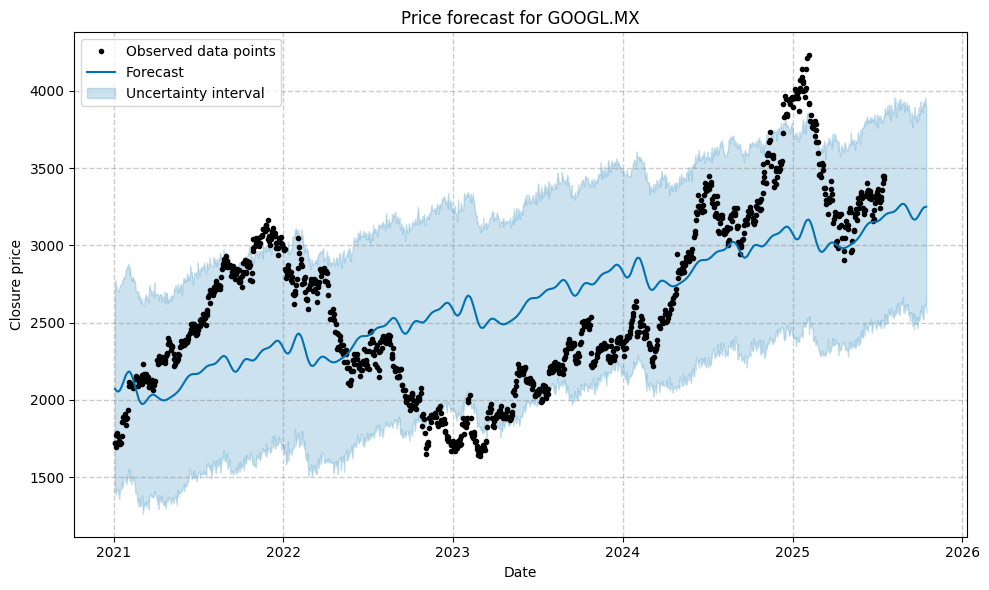

Tiempo de ejecución: 120 segundos
Tiempo de ejecución: 0 horas, 2 minutos y  0 segundos
Mejores hiperparámetros:
{'growth': 'linear', 'changepoint_prior_scale': 0.0013505039499386105, 'seasonality_prior_scale': 0.8820981215126883, 'holidays_prior_scale': 2.287781826837995, 'weekly_seasonality': False}
RMSE óptimo: 549.6161


In [ ]:
trainer('GOOGL.MX')

## Modular packaging into `.py`

In [3]:
import os
code = """
def trainer(ticker, trials=1, FHi='2021-01-01', FHe="", ini=400, peri=10, hori=1, guardar=False, graficar=True, logi=False):
  import time
  start = time.time()

  '''
  Entrena un modelo Prophet para el ticker especificado usando optimización con Optuna.

  Parámetros:
  - ticker (str): símbolo del activo (ej. 'AMD.MX')
  - trials (int): número de iteraciones de búsqueda de hiperparámetros
  - FHi (str): fecha de inicio para descarga de datos (formato 'YYYY-MM-DD')
  - guardar (bool): si se desea guardar el modelo entrenado

  Retorna:
  - modelo (Prophet): objeto Prophet entrenado
  '''

  import yfinance as yf
  import pandas as pd
  import optuna
  import pickle
  import os
  import matplotlib.pyplot as plt
  from datetime import datetime, timedelta
  from prophet import Prophet
  from prophet.diagnostics import cross_validation, performance_metrics

  import logging
  optuna.logging.set_verbosity(optuna.logging.CRITICAL)
  for logger_name in ["cmdstanpy", "prophet"]:
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.CRITICAL)
    logger.propagate = False  # evita que se propague al logger raíz
    for handler in logger.handlers:
      logger.removeHandler(handler)


  ticker = ticker.upper()
  ticker_id = ticker.lower().replace('.', '').replace('-', '')
  if FHe == "":
    FHe = datetime.today().strftime('%Y-%m-%d')
  DatAss = yf.download(ticker, start=FHi, end=FHe, auto_adjust=True)['Close']

  df_prophet = DatAss.reset_index().copy()
  df_prophet['ds'] = DatAss.index
  df_prophet['y'] = df_prophet[ticker]
  df_prophet = df_prophet[['ds', 'y']]

  # Definir función objetivo para Optuna
  def objective(trial):

    # Hiperparámetros a optimizar
    growth_options = ['linear', 'logistic'] if logi else ['linear']
    growth = trial.suggest_categorical('growth', growth_options)
    changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True)
    holidays_prior_scale = trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True)
    weekly_seasonality = trial.suggest_categorical('weekly_seasonality', [True, False])

    # Si usamos crecimiento logístico, necesitamos agregar la columna 'cap'
    if growth == 'logistic':
      df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

    # Definir y entrenar modelo
    model = Prophet(
      growth=growth,
      changepoint_prior_scale=changepoint_prior_scale,
      seasonality_prior_scale=seasonality_prior_scale,
      holidays_prior_scale=holidays_prior_scale,
      weekly_seasonality=weekly_seasonality,
      daily_seasonality=True
    )
    model.fit(df_prophet)

    # Validación cruzada temporal
    df_cv = cross_validation(model, initial=f'{ini} days', period=f'{peri} days', horizon=f'{hori} days')
    df_perf = performance_metrics(df_cv)

    # Retornamos el RMSE promedio
    return df_perf['rmse'].mean()

  study = optuna.create_study(direction='minimize')
  study.optimize(objective, n_trials=trials)

  print('Best hiperparameters:')
  print(study.best_params)

  # Definir modelo con hiperparámetros óptimos
  modelo = Prophet(
    **study.best_params,
    daily_seasonality=True
  )
  # Entrenar sobre toda la base
  if study.best_params['growth'] == 'logistic':
    df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

  modelo.fit(df_prophet)

  df_cv = cross_validation(modelo, initial=f'{ini} days', period=f'{peri} days', horizon=f'{hori} days')
  df_perf = performance_metrics(df_cv)
  print(f'🧠 Entrenamiento completado para {ticker} con RMSE promedio: {df_perf["rmse"].mean():.4f}')

  future = modelo.make_future_dataframe(periods=hori)
  if study.best_params['growth'] == 'logistic':
    future['cap'] = df_prophet['cap'].iloc[0]

  # Predecir con modelo final
  forecast = modelo.predict(future)

  if graficar:
    modelo.plot(forecast)
    plt.title(f'Price forecast for {ticker}')
    plt.xlabel("Date")
    plt.ylabel("Closure price")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend()
    plt.show()

  carpeta_modelos = '/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/'
  if guardar:
    nombre_archivo = f'model_{ticker_id}_{hori}.pkl'
    ruta = os.path.join(carpeta_modelos, nombre_archivo)

    with open(ruta, 'wb') as f:
      pickle.dump(modelo, f)

    print(f'✅ Modelo guardado en: {ruta}')

  end = time.time()
  hrs = (end - start)//3600
  min = ((end - start)%3600)//60
  seg = (end - start)%60
  print(f'Tiempo de ejecución: {(end - start):.0f} segundos')
  print(f'Tiempo de ejecución: {hrs:.0f} horas, {min:.0f} minutos y  {seg:.0f} segundos')
  print("Mejores hiperparámetros:")
  print(study.best_params)
  print(f"RMSE óptimo: {study.best_value:.4f}")
  return modelo
"""

with open("/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/trainer.py", "w") as file:
    file.write(code)